In [1]:
# importing requered libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns



In [2]:
# loading dataset

df= pd.read_csv("Books_Data.csv")

# printing the dataset

df.head()
df.info()
print(df.describe())
df.isnull().sum()
df.shape









<class 'pandas.DataFrame'>
RangeIndex: 1070 entries, 0 to 1069
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   index                1070 non-null   int64  
 1   Publishing Year      1069 non-null   float64
 2   Book Name            1047 non-null   str    
 3   Author               1070 non-null   str    
 4   language_code        1017 non-null   str    
 5   Author_Rating        1070 non-null   str    
 6   Book_average_rating  1070 non-null   float64
 7   Book_ratings_count   1070 non-null   int64  
 8   genre                1070 non-null   str    
 9   gross sales          1070 non-null   float64
 10  publisher revenue    1070 non-null   float64
 11  sale price           1070 non-null   float64
 12  sales rank           1070 non-null   int64  
 13  Publisher            1070 non-null   str    
 14  units sold           1070 non-null   int64  
dtypes: float64(5), int64(4), str(6)
memory usage: 125

(1070, 15)

In [3]:
# checking the datatype and null value are changed or not!

df.info()
df.to_csv('cleaned_books_data.csv',index=False)

<class 'pandas.DataFrame'>
RangeIndex: 1070 entries, 0 to 1069
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   index                1070 non-null   int64  
 1   Publishing Year      1069 non-null   float64
 2   Book Name            1047 non-null   str    
 3   Author               1070 non-null   str    
 4   language_code        1017 non-null   str    
 5   Author_Rating        1070 non-null   str    
 6   Book_average_rating  1070 non-null   float64
 7   Book_ratings_count   1070 non-null   int64  
 8   genre                1070 non-null   str    
 9   gross sales          1070 non-null   float64
 10  publisher revenue    1070 non-null   float64
 11  sale price           1070 non-null   float64
 12  sales rank           1070 non-null   int64  
 13  Publisher            1070 non-null   str    
 14  units sold           1070 non-null   int64  
dtypes: float64(5), int64(4), str(6)
memory usage: 125

In [4]:
# handling string null values

df['Book Name']= df['Book Name'].fillna('Unknown')
df['Book Name'].isnull().sum()

df['language_code']= df['language_code'].fillna('Unknown')

df['language_code'].isnull().sum()

df.isnull().sum()
np.isinf(df['publisher revenue']).sum()
df.columns

df['publisher revenue']=  df['publisher revenue'].replace(0,df['publisher revenue'].mean())
df['publisher revenue']

# dealing with negative and null values
df.loc[df['Publishing Year'] < 1800, 'Publishing Year'] = 1800



## by using the histogram analysing the frequency of publishing year

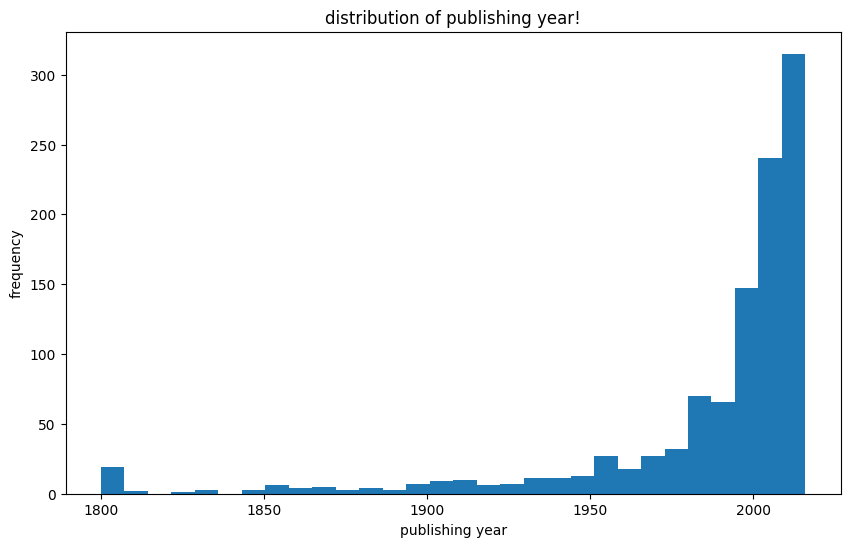

In [15]:
# checking the frequency of the publishing year
plt.figure(figsize=(10,6))
plt.hist(df['Publishing Year'],bins=30)
plt.xlabel('publishing year')
plt.ylabel('frequency')
plt.title('distribution of publishing year!')
plt.savefig('didtribution of publishing year.png')
plt.show()

# from above chart we can understand the 1990-2010 is most published year in dataset means in 1990-2010 the maximum book are published as compared to other

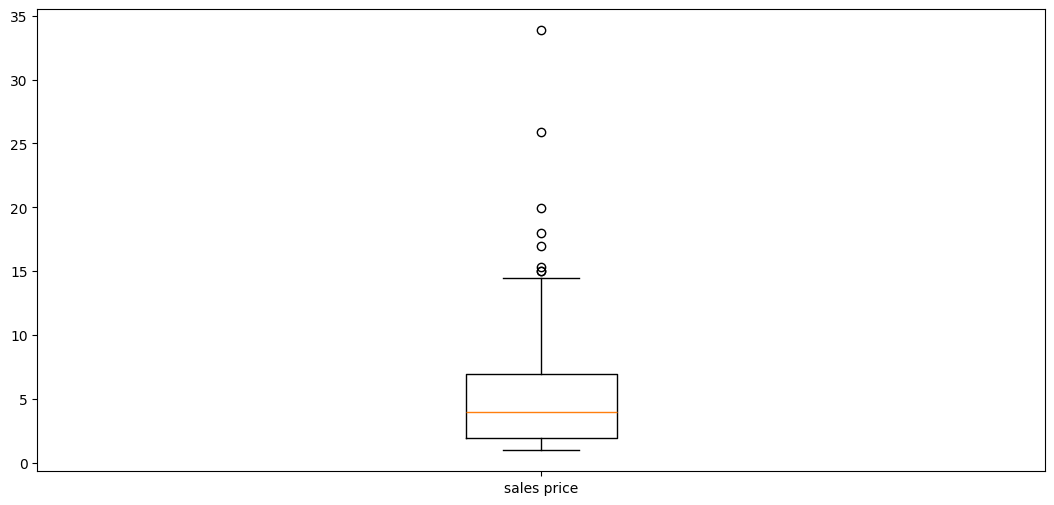

In [6]:
# Checking the outliers in  publishing year
plt.figure(figsize=(13,6))
plt.boxplot(df[ 'sale price'],
            tick_labels=['sales price'])
plt.show()

 # by analysing the above boxplot we understand the  outliers are pesent in the sales price 

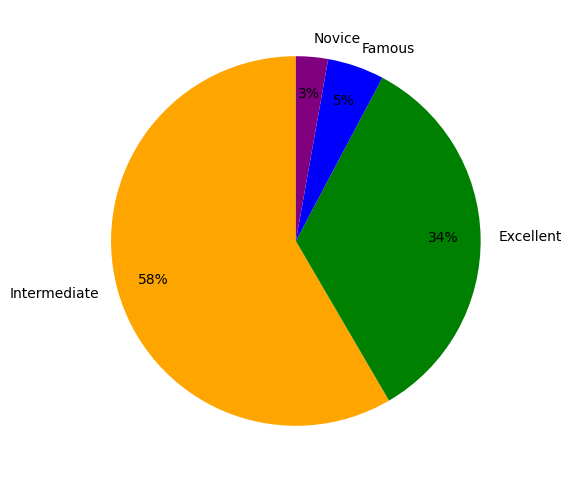

In [7]:
#checking the frequency of author_rating by using pie chart

x= df['Author_Rating'].value_counts()
plt.figure(figsize=(12,6))
plt.pie(x ,autopct='%1.0f%%',colors=['orange','green','blue','purple'],labels=x.index,startangle=90 ,pctdistance=0.8)
plt.show()




# from the above pie chart we can say that the   58% people gives the 'intermediate' rating and 34% gives  'Excellent' rating

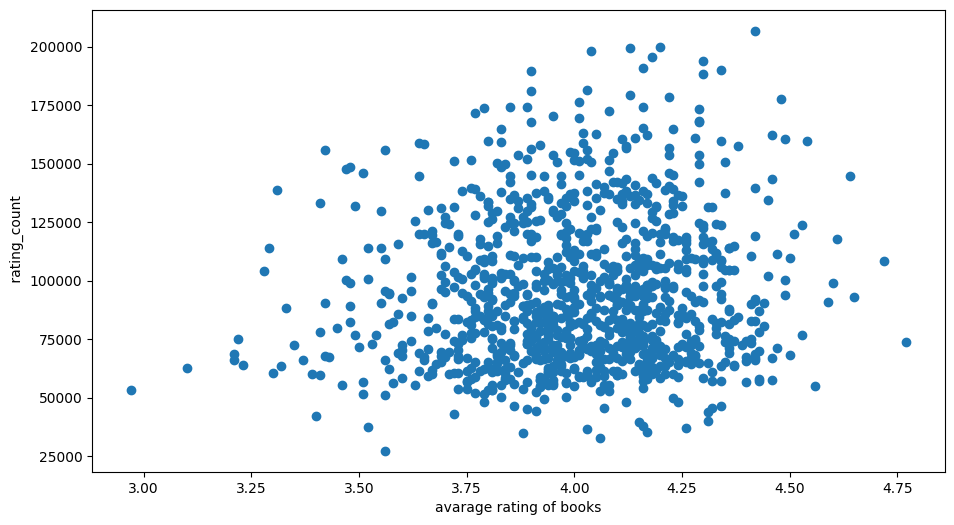

In [8]:
# finding  the relation between  'Book_average_rating' and  'Book_ratings_count' using scatter plot

x = df['Book_average_rating']
y = df['Book_ratings_count']

plt.figure(figsize=(11,6))
plt.scatter(x,y)
plt.xlabel('avarage rating of books')
plt.ylabel(' rating_count')
plt.show()

# from the above scatter plot we can say that the avarage rating is between the 3.75 to 4.25.and the higheast rating count also belongs to this range

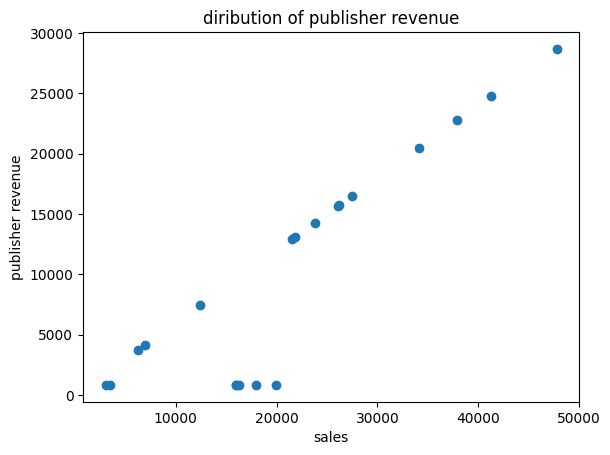

In [9]:
# comparing the sale and publisher revenue using scatter plot
x = df[ 'gross sales'].head(20)
y = df['publisher revenue'].head(20)

plt.scatter(x,y)
plt.title("diribution of publisher revenue")
plt.xlabel('sales')
plt.ylabel('publisher revenue')
plt.show()

 # from this one thing we  understand that the sale is directly proportional to the publisher revenue means if seles is increases then the revenue also increases

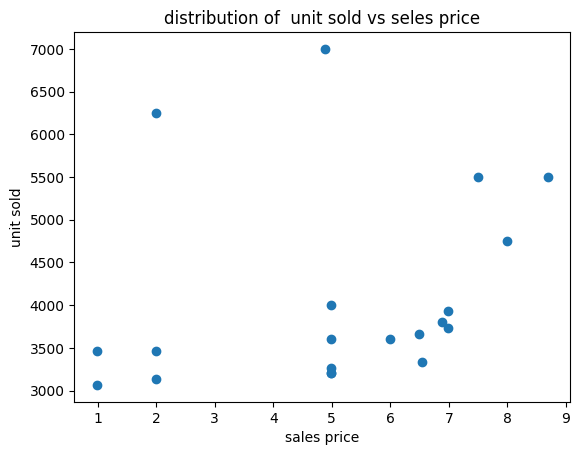

In [10]:
# comparing sales price and unit sold
x = df[ 'sale price'].head(20)
y = df['units sold'].head(20)

plt.scatter(x,y)
plt.title("distribution of  unit sold vs seles price")
plt.xlabel('sales price')
plt.ylabel('unit sold')
plt.show()

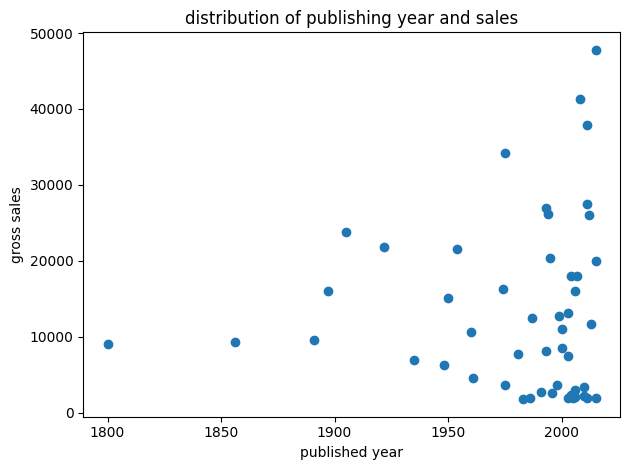

In [11]:
x = df['Publishing Year'].head(50)
y= df ['gross sales'].head(50)
plt.scatter(x,y)
plt.title("distribution of publishing year and sales")
plt.xlabel('published year')
plt.ylabel('gross sales')
plt.tight_layout()
plt.show()






# by analysing the above scatter plot we understand that the in 1950 to 2000 there are most books are published with higher gross sales

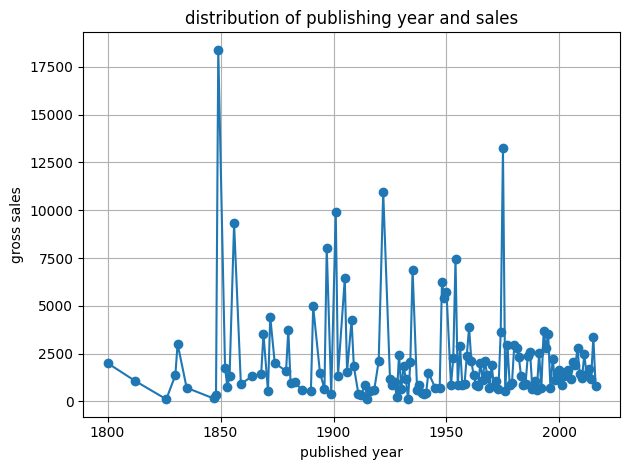

In [12]:
yearly_sales= (
    df.groupby('Publishing Year')[ 'gross sales'].mean().sort_index()
)

plt.plot(yearly_sales.index,yearly_sales.values,marker='o')
plt.title("distribution of publishing year and sales")
plt.xlabel('published year')
plt.ylabel('gross sales')
plt.grid()
plt.tight_layout()
plt.show()


# by ploting the published year into a plot we can easily  understand  that the in 1845-1850 the highest sales of the books

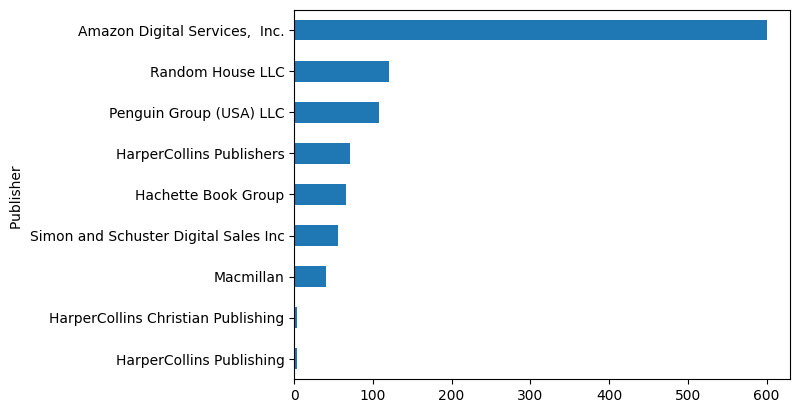

<Figure size 1200x600 with 0 Axes>

In [17]:
df['Publisher '].value_counts().sort_values().plot(kind='barh')
plt.figure(figsize=(12,6))


plt.tight_layout()
plt.show()


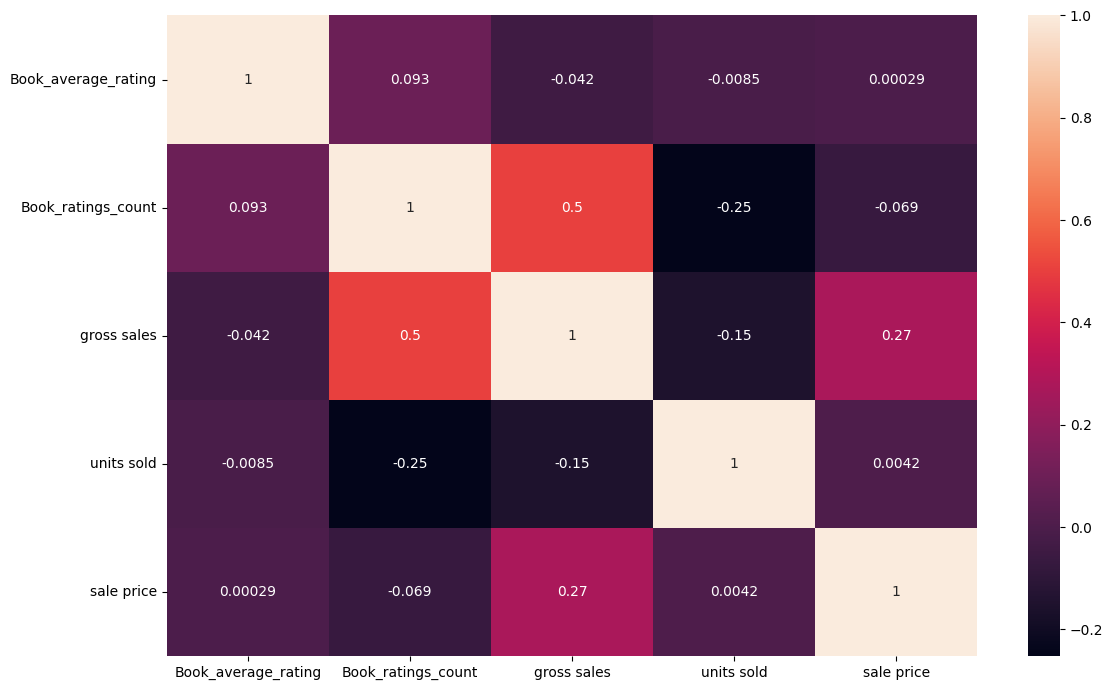

In [18]:
# using heatmap  analysing the correlation betweens the numeric columns
corr =df[['Book_average_rating','Book_ratings_count','gross sales', 'units sold','sale price']].corr()
plt.figure(figsize=(12,7))

sns.heatmap(corr ,annot=True,)
plt.savefig('heatmap_of_books_dataset.png')

plt.tight_layout()

plt.show()

# conclusion of above heatmap 

Ratings Count $\rightarrow$ High Sales (0.50): The number of ratings/reviews a book has is the strongest driver of total sales revenue.

Average Rating Doesn't Matter ($\approx$ 0): Whether a book is rated 3 stars or 5 stars has almost zero impact on its sales, price, or popularity.

Price Matters Slightly (0.27): Higher sale prices contribute moderately to higher gross revenue, but price does not affect how many individual units are sold.